In [2]:
!py -m pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.2 MB 3.9 MB/s eta 0:00:01
   --------------- ------------------------ 1.6/4.2 MB 4.0 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.2 MB 4.3 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.2 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 4.2 MB/s  0:00:01
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.1 MB 4.3 MB/s eta 0:00:29
    --------------------------------------- 1.8/122.1 MB 4.4 MB/s eta 0:00:28
    --------------------------------------- 2.6/122.1 MB 4.4 MB/s eta 0:00:28
   - -------------------------------------- 3.7/122.1 MB 4.4 MB/s eta 0:00:28
   - --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy import stats, ndimage
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


Cell 2 — Config: noise parameters from your Q1/tail-shape results

In [ ]:

GGD_BETA   = 0.845    # Generalized Gaussian shape (winner)
GGD_SCALE  = 0.044
T_DF       = 2.52     # Student-t degrees of freedom (independent corroboration)
T_SCALE    = 0.051

IMG_SIZE   = 128
N_ITERS    = 300
LR         = 0.05
OUTLIER_FRACTION = 0.02   
OUTLIER_SCALE = 0.6
REG_LAMBDA = 8.0  
N_ITERS = 400

Cell 3 — Synthetic clean signal (wafer-like structure)

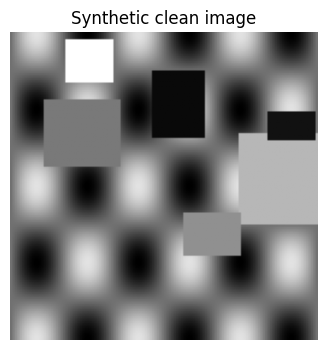

In [3]:
def make_synthetic_clean(size=IMG_SIZE):
    x = np.linspace(0, 1, size)
    xx, yy = np.meshgrid(x, x)
    img = 0.5 + 0.3 * np.sin(6 * np.pi * xx) * np.cos(4 * np.pi * yy)
    # add some rectangular "structure" blocks
    for _ in range(6):
        cx, cy = np.random.randint(10, size-10, size=2)
        w, h = np.random.randint(5, 20, size=2)
        val = np.random.uniform(0.1, 0.9)
        img[max(0,cy-h):cy+h, max(0,cx-w):cx+w] = val
    img = np.clip(img, 0, 1)
    return img.astype(np.float64)

clean = make_synthetic_clean()

plt.figure(figsize=(4,4))
plt.imshow(clean, cmap="gray")
plt.title("Synthetic clean image")
plt.axis("off")
plt.show()

Cell 4 — Add heavy-tailed noise (matched to your fitted distribution) + extreme outliers

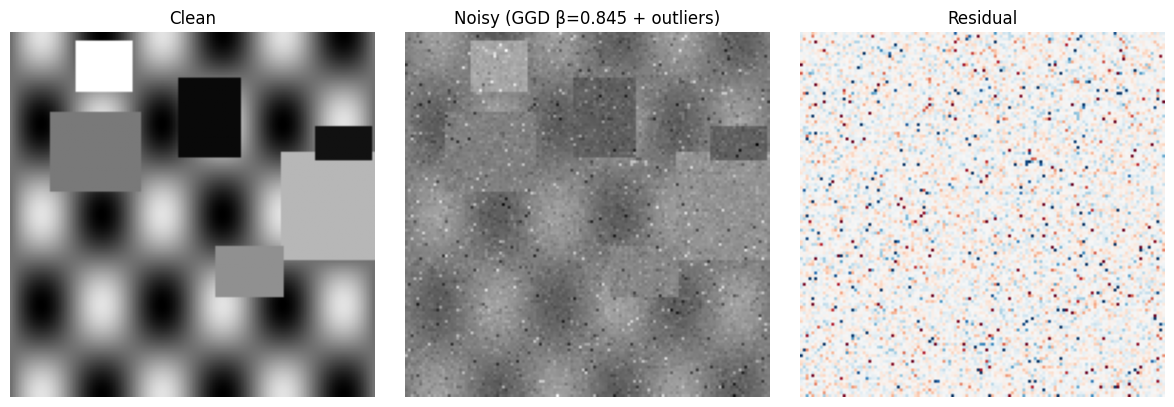

Injected outlier pixels: 331 (2.02%)


In [4]:
noise = stats.gennorm.rvs(GGD_BETA, loc=0, scale=GGD_SCALE, size=clean.shape, random_state=42)

outlier_mask = np.random.rand(*clean.shape) < OUTLIER_FRACTION
outlier_noise = np.random.choice([-1, 1], size=clean.shape) * OUTLIER_SCALE * outlier_mask

noisy = clean + noise + outlier_noise

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(clean, cmap="gray"); axes[0].set_title("Clean"); axes[0].axis("off")
axes[1].imshow(noisy, cmap="gray"); axes[1].set_title("Noisy (GGD β=0.845 + outliers)"); axes[1].axis("off")
axes[2].imshow(noisy - clean, cmap="RdBu", vmin=-0.6, vmax=0.6); axes[2].set_title("Residual"); axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Injected outlier pixels: {outlier_mask.sum()} ({100*outlier_mask.mean():.2f}%)")

Cell 5 — Define the 5 loss functions + plot their shape and gradient

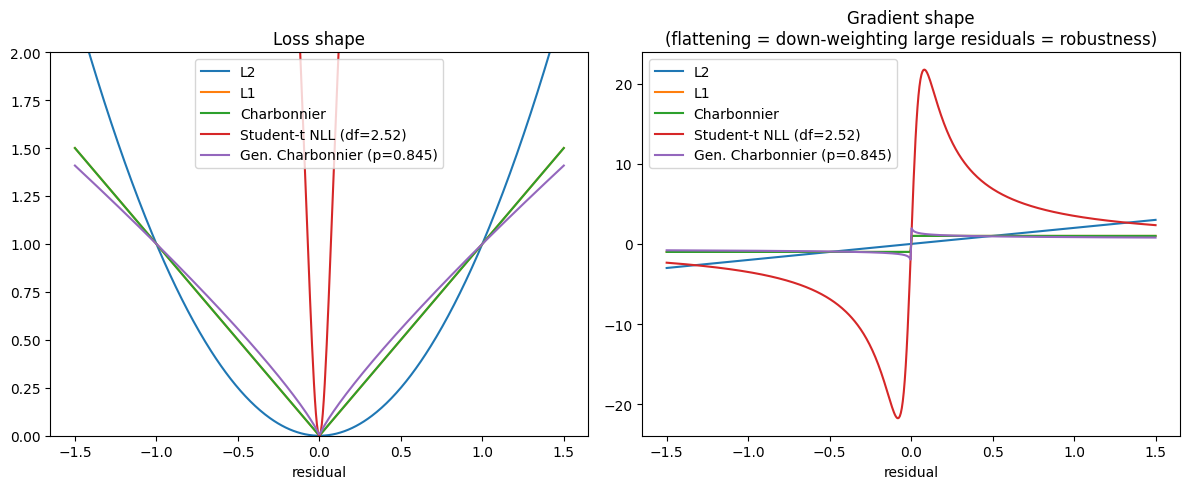

In [5]:
def loss_l2(r):
    return r**2

def loss_l1(r):
    return torch.abs(r)

def loss_charbonnier(r, eps=1e-3):
    return torch.sqrt(r**2 + eps**2)

def loss_student_t(r, df=T_DF, scale=T_SCALE):
    # negative log-likelihood of Student-t (up to additive constant)
    return (df + 1) / 2 * torch.log(1 + (r / scale)**2 / df)

def loss_gen_charbonnier(r, p=GGD_BETA, eps=1e-3):
    return (r**2 + eps**2) ** (p / 2)

losses = {
    "L2": loss_l2,
    "L1": loss_l1,
    "Charbonnier": loss_charbonnier,
    "Student-t NLL (df=2.52)": loss_student_t,
    "Gen. Charbonnier (p=0.845)": loss_gen_charbonnier,
}

r_axis = torch.linspace(-1.5, 1.5, 500, requires_grad=True)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for name, fn in losses.items():
    y = fn(r_axis)
    axes[0].plot(r_axis.detach(), y.detach(), label=name)
    grad = torch.autograd.grad(y.sum(), r_axis, retain_graph=True)[0]
    axes[1].plot(r_axis.detach(), grad.detach(), label=name)
    r_axis.grad = None

axes[0].set_title("Loss shape"); axes[0].set_xlabel("residual"); axes[0].legend(); axes[0].set_ylim(0, 2)
axes[1].set_title("Gradient shape\n(flattening = down-weighting large residuals = robustness)")
axes[1].set_xlabel("residual"); axes[1].legend()
plt.tight_layout()
plt.show()

Cell 6 — Recovery routine (no network — just optimize pixel values directly under each loss)

In [6]:
def tv_smoothness(x):
    # simple 4-neighbor squared-difference smoothness prior (image gradient penalty)
    dx = x[:, 1:] - x[:, :-1]
    dy = x[1:, :] - x[:-1, :]
    return (dx**2).sum() + (dy**2).sum()

def recover(noisy_img, loss_fn, n_iters=N_ITERS, lr=LR, reg_lambda=REG_LAMBDA):
    noisy_t = torch.tensor(noisy_img, dtype=torch.float32, device=device)
    x_hat = noisy_t.clone().requires_grad_(True)
    optimizer = torch.optim.Adam([x_hat], lr=lr)

    for _ in range(n_iters):
        optimizer.zero_grad()
        residual = x_hat - noisy_t
        data_loss = loss_fn(residual).mean()
        smooth_loss = tv_smoothness(x_hat) / x_hat.numel()
        loss = data_loss + reg_lambda * smooth_loss
        loss.backward()
        optimizer.step()

    return x_hat.detach().cpu().numpy()

Cell 7 — Run recovery for every loss

In [7]:
recovered = {}
for name, fn in losses.items():
    recovered[name] = recover(noisy, fn)
    print(f"done: {name}")

done: L2
done: L1
done: Charbonnier
done: Student-t NLL (df=2.52)
done: Gen. Charbonnier (p=0.845)


Cell 8 — Metrics (MAE, RMSE, PSNR, SSIM) per loss

In [8]:
def psnr(a, b, data_range=1.0):
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return np.inf
    return 20 * np.log10(data_range) - 10 * np.log10(mse)

def simple_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    mu_a = ndimage.uniform_filter(a, win)
    mu_b = ndimage.uniform_filter(b, win)
    sigma_a = ndimage.uniform_filter(a**2, win) - mu_a**2
    sigma_b = ndimage.uniform_filter(b**2, win) - mu_b**2
    sigma_ab = ndimage.uniform_filter(a*b, win) - mu_a*mu_b
    ssim_map = ((2*mu_a*mu_b + C1)*(2*sigma_ab + C2)) / ((mu_a**2+mu_b**2+C1)*(sigma_a+sigma_b+C2))
    return ssim_map.mean()

print(f"{'Loss':<28} {'MAE':>8} {'RMSE':>8} {'PSNR':>8} {'SSIM':>8}")
print("-"*64)
mae_noisy = np.mean(np.abs(noisy - clean))
print(f"{'(noisy, unrecovered)':<28} {mae_noisy:>8.4f} {np.sqrt(np.mean((noisy-clean)**2)):>8.4f} "
      f"{psnr(noisy, clean):>8.3f} {simple_ssim(noisy, clean):>8.4f}")
for name, rec in recovered.items():
    mae = np.mean(np.abs(rec - clean))
    rmse = np.sqrt(np.mean((rec - clean) ** 2))
    p = psnr(rec, clean)
    s = simple_ssim(rec, clean)
    print(f"{name:<28} {mae:>8.4f} {rmse:>8.4f} {p:>8.3f} {s:>8.4f}")

Loss                              MAE     RMSE     PSNR     SSIM
----------------------------------------------------------------
(noisy, unrecovered)           0.0689   0.1196   18.443   0.3378
L2                             0.0363   0.0512   25.815   0.8550
L1                             0.0229   0.0350   29.127   0.8624
Charbonnier                    0.0228   0.0349   29.154   0.8632
Student-t NLL (df=2.52)        0.0537   0.0777   22.189   0.4850
Gen. Charbonnier (p=0.845)     0.0250   0.0361   28.855   0.8339


Cell 9 — Visual comparison grid

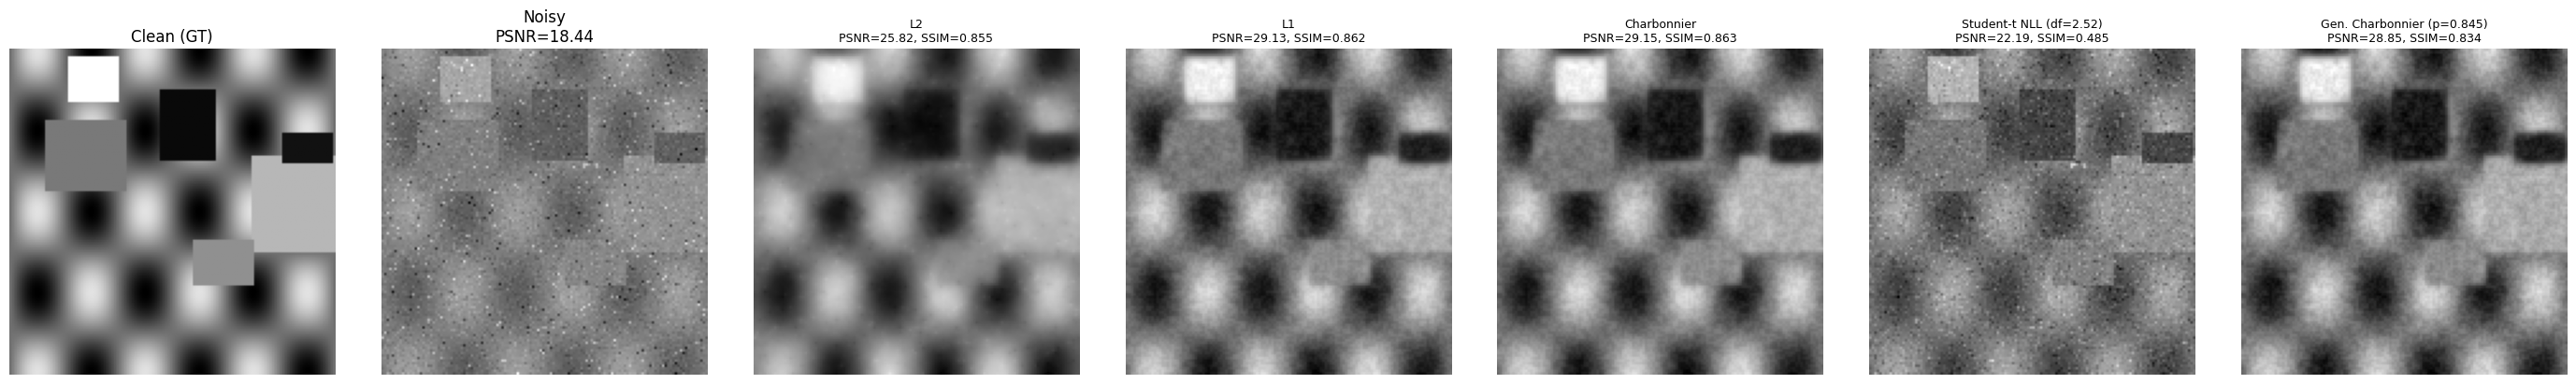

In [9]:
fig, axes = plt.subplots(1, len(recovered)+2, figsize=(4*(len(recovered)+2), 4))
axes[0].imshow(clean, cmap="gray"); axes[0].set_title("Clean (GT)"); axes[0].axis("off")
axes[1].imshow(noisy, cmap="gray"); axes[1].set_title(f"Noisy\nPSNR={psnr(noisy,clean):.2f}"); axes[1].axis("off")
for ax, (name, rec) in zip(axes[2:], recovered.items()):
    ax.imshow(rec, cmap="gray")
    ax.set_title(f"{name}\nPSNR={psnr(rec,clean):.2f}, SSIM={simple_ssim(rec,clean):.3f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Cell 10 — The key test: recovery specifically at the injected extreme-outlier pixels

C:\Users\gk192\AppData\Local\Temp\ipykernel_6672\996649695.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(outlier_errors.values(), labels=outlier_errors.keys(), showfliers=False)


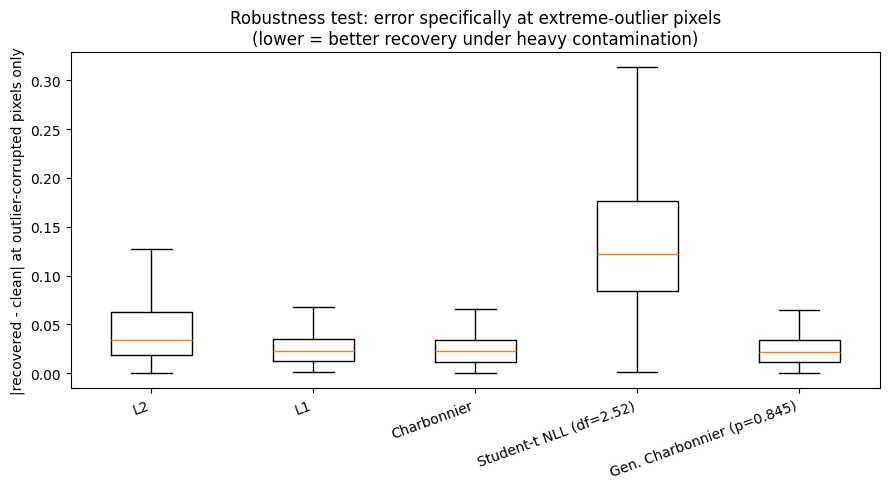

Loss                          mean err @ outliers
L2                                         0.0437
L1                                         0.0280
Charbonnier                                0.0278
Student-t NLL (df=2.52)                    0.1439
Gen. Charbonnier (p=0.845)                 0.0266


In [10]:
outlier_errors = {}
for name, rec in recovered.items():
    err_at_outliers = np.abs(rec[outlier_mask] - clean[outlier_mask])
    outlier_errors[name] = err_at_outliers

plt.figure(figsize=(9,5))
plt.boxplot(outlier_errors.values(), labels=outlier_errors.keys(), showfliers=False)
plt.xticks(rotation=20, ha="right")
plt.ylabel("|recovered - clean| at outlier-corrupted pixels only")
plt.title("Robustness test: error specifically at extreme-outlier pixels\n(lower = better recovery under heavy contamination)")
plt.tight_layout()
plt.show()

print(f"{'Loss':<28} {'mean err @ outliers':>20}")
for name, errs in outlier_errors.items():
    print(f"{name:<28} {errs.mean():>20.4f}")

Cell 11 — Summary

In [11]:
best_overall = min(recovered, key=lambda k: np.mean(np.abs(recovered[k]-clean)))
best_outlier = min(outlier_errors, key=lambda k: outlier_errors[k].mean())
print(f"Best overall MAE: {best_overall}")
print(f"Best at outlier-only pixels: {best_outlier}")
print("\nExpectation to check: Gen. Charbonnier / Student-t should win (or tie for best)")
print("on the outlier-only boxplot even if L2 looks competitive on the full-image metrics,")
print("since that's specifically where heavy-tail robustness should show up.")

Best overall MAE: Charbonnier
Best at outlier-only pixels: Gen. Charbonnier (p=0.845)

Expectation to check: Gen. Charbonnier / Student-t should win (or tie for best)
on the outlier-only boxplot even if L2 looks competitive on the full-image metrics,
since that's specifically where heavy-tail robustness should show up.
